# Notebook 09 — Surface→Subsurface NEB
## Hastelloy N | Hydrogen Interaction Study

---

> **Guiding Principle:** Start from the smallest possible piece. Build confidence at each step before adding complexity.

**What this notebook computes:**
- MEP for H* migrating from the surface bridge site into the first subsurface octahedral site
- Absorption barrier E_abs (surface → subsurface)
- Desorption barrier E_des (subsurface → surface)

**Method:** ASE CINEB + MACECalculator, 1 A100 GPU, sequential force calls

**Inputs (from logs — no hardcoding):**
- `structures/notebook06/h_atom_bridge_relaxed.lammps` — IS: single H* at bridge (NB06)
- `structures/notebook08/sub_<best>_relaxed.lammps` — FS: H* at best subsurface site (NB08)
- `results/notebook06/h_atom_bridge.log` — E(IS)
- `results/notebook08/subsurface_energies.txt` → `results/notebook08/sub_<best>.log` — E(FS)

**Outputs:**
- `results/notebook09/neb09_barrier.txt` — E_abs, E_des, ΔE
- `results/notebook09/neb09_path.dat` — MEP energies
- `results/notebook09/fig_mep.png` — MEP plot

**Next notebook:** `10_bulk_equilibration.ipynb`

---
**Key parameters:**
```
IS          : H* at bridge site (surface, NB06)
FS          : H* at best subsurface O site (NB08)
N images    : 9 intermediate + IS + FS = 11 total
Interpolation: IDPP
Spring k    : 1.0 eV/Å²
Ftol        : 0.05 eV/Å
Phase 1     : 2000 steps regular NEB
Phase 2     : 5000 steps CINEB
```
---
**Citation style:** ACS — inline [N], full list in Section 5.

---
## 1. Theory & Background
---

### 1.1 Surface→Subsurface Barrier

Hydrogen permeation through a metal involves three sequential steps [1,2]:
```
H₂(g)  → 2H*      dissociation barrier  E_diss  (NB06)
H*     → H_sub    absorption barrier    E_abs   (NB09 ← this notebook)
H_sub  → H_bulk   diffusion barrier     E_diff  (NB11-12)
```

From the MEP we extract:
$$E_{abs} = E_{TS} - E_{IS}$$
$$E_{des} = E_{TS} - E_{FS}$$

Since ΔH_sol(O19) = −0.41 eV (exothermic from NB08), the FS is lower than the IS — E_des > E_abs.

**Key references:** [1,2,3]

### 1.2 FIRE Minimizer for NEB

LAMMPS NEB requires an explicit time-integration minimizer — CG is not allowed because NEB forces are not conservative [4,5].

| Minimizer | Kokkos variant | NEB compatible |
|-----------|---------------|----------------|
| `quickmin` | none | ✓ (but fails with Kokkos GPU) |
| `fire` | `fire/kk` ✓ | ✓ |

FIRE (Fast Inertial Relaxation Engine) [6] adaptively adjusts the timestep and velocity direction. It is equivalent to quickmin for NEB and fully Kokkos-compatible. Use `min_style fire` — LAMMPS automatically invokes `fire/kk` when Kokkos is active.

**Key references:** [4,5,6]

---
## 2. Execution Strategy
---

### What We Are Doing in This Notebook

```
3.1  Imports, parameters — read IS/FS energies from logs
3.2  Verify IS and FS structures
3.3  Prepare IS (strip Velocities, copy to notebook09)
3.4  Write ASE CINEB script and submit (1 A100)
3.5  Parse NEB results — extract E_abs, E_des, ΔE
3.6  Plot MEP
3.7  Decision cell
```

---
## 3. Code
---

### 3.1 — Imports, Parameters & Read Previous Results

In [1]:
import numpy as np
import os
import subprocess
import matplotlib.pyplot as plt
from ase.io import read
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD        = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL_LAMMPS = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
MACE_MODEL_ASE    = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model'
MACE_MODEL        = MACE_MODEL_LAMMPS
KOKKOS_FLAGS      = ['-k', 'on', 'g', '1', '-sf', 'kk',
                     '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '06:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping ────────────────────────────────────────
ELEM_STR        = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE      = 'mliap unified'
PAIR_SUFFIX     = '0'
Z_FREEZE_CUTOFF = 18.10   # Å — bottom 2 layers (NB04)

# ── NEB parameters ───────────────────────────────────────────
N_REPLICAS  = 9       # intermediate images
SPRING_CONST = 1.0   # eV/Å²
NEB_FTOL    = 0.05   # eV/Å
N1_STEPS    = 2000   # phase 1: regular NEB steps
NEB_STEPS   = 5000   # phase 2: CINEB steps

# ── File paths ───────────────────────────────────────────────
# IS: single H* at bridge from NB06 (NOT the H2 adsorption file)
#NEB09_IS_SRC  = 'structures/notebook06/h_atom_bridge_relaxed.lammps'
#NEB09_IS_SRC = 'structures/notebook06/h_atom_fcc_hollow_relaxed.lammps'
NEB09_IS_SRC = 'structures/notebook06/h_atom_fcc_hollow_relaxed.lammps'
NEB09_IS_FILE = 'structures/notebook09/neb09_initial.lammps'

for d in ['structures/notebook09', 'results/notebook09',
          'lammps_scripts/notebook09', 'slurm_scripts/notebook09']:
    os.makedirs(d, exist_ok=True)

# ── Helper ───────────────────────────────────────────────────
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

# ═══════════════════════════════════════════════════════════
# READ PREVIOUS RESULTS FROM LOGS — NO HARDCODING
# ═══════════════════════════════════════════════════════════
print('Reading reference energies from logs...')
print()

# IS: single H* at bridge — from NB06 h_atom_bridge job
#res_is = parse_energy_log('results/notebook06/h_atom_fcc_hollow.log')
res_is = parse_energy_log('results/notebook06/h_atom_fcc_hollow.log')
if res_is:
    E_IS = res_is['pe_final_eV']
    print(f'E_IS (H* bridge) = {E_IS:.6f} eV  [notebook06/h_atom_bridge.log]')
else:
    raise FileNotFoundError(
        'results/notebook06/h_atom_bridge.log not found.\n'
        'Complete Notebook 06 (cell 3.2 submits h_atom_bridge job).')

# FS: best subsurface site from NB08
BEST_SUB_LABEL = None
E_FS = None

sub_energies_file = 'results/notebook08/subsurface_energies.txt'
if os.path.exists(sub_energies_file):
    with open(sub_energies_file) as f:
        for line in f:
            if 'Most stable:' in line:
                BEST_SUB_LABEL = line.split()[2]
                break
    if BEST_SUB_LABEL:
        res_fs = parse_energy_log(f'results/notebook08/sub_{BEST_SUB_LABEL}.log')
        if res_fs:
            E_FS = res_fs['pe_final_eV']
            print(f'E_FS ({BEST_SUB_LABEL})      = {E_FS:.6f} eV  '
                  f'[notebook08/sub_{BEST_SUB_LABEL}.log]')
        else:
            raise FileNotFoundError(
                f'results/notebook08/sub_{BEST_SUB_LABEL}.log not found.')
    else:
        raise ValueError('Could not parse best site from subsurface_energies.txt')
else:
    raise FileNotFoundError(
        f'{sub_energies_file} not found. Complete Notebook 08.')

# FS structure file
NEB09_FS_FILE = f'structures/notebook08/sub_{BEST_SUB_LABEL}_relaxed.lammps'
if not os.path.exists(NEB09_FS_FILE):
    raise FileNotFoundError(
        f'{NEB09_FS_FILE} not found. Complete Notebook 08.')

delta_E = E_FS - E_IS
print()
print(f'delta_E (FS-IS) = {delta_E:.4f} eV  '
      f'({"exothermic" if delta_E < 0 else "endothermic"})')
print(f'IS: H* at bridge (surface)')
print(f'FS: H* at {BEST_SUB_LABEL} (subsurface, best from NB08)')
print(f'FS file: {NEB09_FS_FILE}')

ASE version : 3.27.0
NumPy       : 2.4.3
Reading reference energies from logs...

E_IS (H* bridge) = -2395.499210 eV  [notebook06/h_atom_bridge.log]
E_FS (O22)      = -2394.242354 eV  [notebook08/sub_O22.log]

delta_E (FS-IS) = 1.2569 eV  (endothermic)
IS: H* at bridge (surface)
FS: H* at O22 (subsurface, best from NB08)
FS file: structures/notebook08/sub_O22_relaxed.lammps


### 3.2 — Verify IS and FS Structures

In [2]:
# ─────────────────────────────────────────────────────────────
# Verify IS and FS — both must have 361 atoms, 1 H atom
# IS: H above surface (z > z_surf)
# FS: H below surface (z < z_surf)
# ─────────────────────────────────────────────────────────────

print('IS/FS Structure Verification')
print('=' * 58)

is_ok = fs_ok = False

# ── IS ────────────────────────────────────────────────────────
if os.path.exists(NEB09_IS_SRC):
    is_slab = read(NEB09_IS_SRC, format='lammps-data', style='atomic')
    is_pos  = is_slab.get_positions()
    is_syms = np.array(is_slab.get_chemical_symbols())
    h_is    = is_pos[is_syms == 'H']
    z_surf  = is_pos[is_syms != 'H'][:, 2].max()

    print(f'IS: {NEB09_IS_SRC}')
    print(f'  Atoms   : {len(is_slab)}  (expect 361)')
    print(f'  H count : {len(h_is)}  (expect 1)')
    print(f'  H z     : {h_is[0, 2]:.4f} A  (surface z = {z_surf:.4f} A)')
    print(f'  H depth : {z_surf - h_is[0, 2]:+.4f} A  (negative = above surface)')
    print(f'  E_IS    : {E_IS:.6f} eV')
    is_ok = (len(is_slab) == 361 and len(h_is) == 1 and h_is[0, 2] > z_surf)
    print(f'  Status  : {"ok" if is_ok else "FAIL"}')
else:
    print(f'IS not found: {NEB09_IS_SRC}')
    print('  Complete Notebook 06 cell 3.2 first.')

print()

# ── FS ────────────────────────────────────────────────────────
if os.path.exists(NEB09_FS_FILE):
    fs_slab   = read(NEB09_FS_FILE, format='lammps-data', style='atomic')
    fs_pos    = fs_slab.get_positions()
    fs_syms   = np.array(fs_slab.get_chemical_symbols())
    h_fs      = fs_pos[fs_syms == 'H']
    z_surf_fs = fs_pos[fs_syms != 'H'][:, 2].max()

    print(f'FS: {NEB09_FS_FILE}')
    print(f'  Atoms   : {len(fs_slab)}  (expect 361)')
    print(f'  H count : {len(h_fs)}  (expect 1)')
    print(f'  H z     : {h_fs[0, 2]:.4f} A  (surface z = {z_surf_fs:.4f} A)')
    print(f'  H depth : {z_surf_fs - h_fs[0, 2]:+.4f} A  (positive = below surface)')
    print(f'  E_FS    : {E_FS:.6f} eV')
    print(f'  delta_E : {delta_E:.4f} eV')
    fs_ok = (len(fs_slab) == 361 and len(h_fs) == 1 and h_fs[0, 2] < z_surf_fs)
    print(f'  Status  : {"ok" if fs_ok else "FAIL"}')
else:
    print(f'FS not found: {NEB09_FS_FILE}')
    print('  Complete Notebook 08 first.')

print()
print('=' * 58)
print(f'  {"ok" if is_ok else "FAIL"} IS: 361 atoms, H above surface')
print(f'  {"ok" if fs_ok else "FAIL"} FS: 361 atoms, H below surface')
if is_ok and fs_ok:
    print('  Both verified — proceed to cell 3.3')
else:
    print('  Resolve FAIL items before proceeding')

IS/FS Structure Verification
IS: structures/notebook06/h_atom_fcc_hollow_relaxed.lammps
  Atoms   : 361  (expect 361)
  H count : 1  (expect 1)
  H z     : 38.7188 A  (surface z = 37.8123 A)
  H depth : -0.9065 A  (negative = above surface)
  E_IS    : -2395.499210 eV
  Status  : ok

FS: structures/notebook08/sub_O22_relaxed.lammps
  Atoms   : 361  (expect 361)
  H count : 1  (expect 1)
  H z     : 36.7990 A  (surface z = 38.0327 A)
  H depth : +1.2337 A  (positive = below surface)
  E_FS    : -2394.242354 eV
  delta_E : 1.2569 eV
  Status  : ok

  ok IS: 361 atoms, H above surface
  ok FS: 361 atoms, H below surface
  Both verified — proceed to cell 3.3


### 3.3 — Prepare IS File

> Strip Velocities from IS and copy to notebook09 structures folder.
> FS is used directly from NB08 — no conversion needed for ASE NEB.

In [3]:
# ─────────────────────────────────────────────────────────────
# Prepare IS: strip Velocities and copy to notebook09 folder
# FS is used directly from NB08 — ASE NEB reads data files
# ─────────────────────────────────────────────────────────────

with open(NEB09_IS_SRC) as f:
    content = f.read()

if 'Velocities' in content:
    content = content[:content.index('Velocities')].rstrip() + '\n'
    print('Stripped Velocities from IS')
else:
    print('No Velocities section in IS')

with open(NEB09_IS_FILE, 'w') as f:
    f.write(content)

print(f'IS written: {NEB09_IS_FILE}')

# Verify
is_check = read(NEB09_IS_FILE, format='lammps-data', style='atomic')
print(f'  Atoms  : {len(is_check)}')
print(f'  H count: {sum(1 for s in is_check.get_chemical_symbols() if s == "H")}')
print()
print(f'FS: {NEB09_FS_FILE}  (used directly from NB08)')
print()
print('Files ready — proceed to cell 3.4')

Stripped Velocities from IS
IS written: structures/notebook09/neb09_initial.lammps
  Atoms  : 361
  H count: 1

FS: structures/notebook08/sub_O22_relaxed.lammps  (used directly from NB08)

Files ready — proceed to cell 3.4


### 3.4 — Write ASE CINEB Script and Submit

> Single NEB: H* at bridge (surface) → H* at best subsurface site.
> IDPP interpolation — avoids atom clashes during surface→subsurface migration.
> Two-phase: regular NEB (phase 1) then climbing image NEB (phase 2).
> Runs on 1 A100 GPU, MACECalculator called sequentially.

In [4]:
# LAMMPS NEB not used — ASE NEB in cell 3.4 below

In [6]:
# ─────────────────────────────────────────────────────────────
# Write ASE CINEB script and submit
# IS: H* at bridge (surface, 361 atoms) — NB06
# FS: H* at best subsurface site (361 atoms) — NB08
# IDPP interpolation — avoids atom clashes during migration
# Two-phase: regular NEB then climbing image NEB
# Endpoint calculator pattern: is_end/fs_end (never copy after attach)
# ─────────────────────────────────────────────────────────────

sc  = SLURM_CONFIG
ld  = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
                for p in sc['ld_paths'])

neb09_py = f'''#!/usr/bin/env python3
"""NEB09: H* surface bridge → subsurface {BEST_SUB_LABEL} — ASE CINEB + MACECalculator
IS: single H* at bridge site (361 atoms) — NB06
FS: H* at subsurface {BEST_SUB_LABEL} (361 atoms) — NB08
Interpolation: IDPP
Two-phase: regular NEB (phase 1) → CINEB (phase 2)
"""

import os, sys, numpy as np, torch
from ase.io import read
from ase.mep import NEB
from ase.optimize import MDMin
from ase.calculators.singlepoint import SinglePointCalculator
from mace.calculators import MACECalculator

_ld = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = ":".join(
    p for p in _ld.split(":") if "stubs" not in p)

# ── Parameters ────────────────────────────────────────────────
MACE_MODEL      = "{MACE_MODEL_ASE}"
NEB09_IS_FILE   = "{NEB09_IS_FILE}"
NEB09_FS_FILE   = "{NEB09_FS_FILE}"
Z_FREEZE_CUTOFF = {Z_FREEZE_CUTOFF}
E_IS            = {E_IS}
E_FS            = {E_FS}
N_IMAGES        = {N_REPLICAS}
NEB_FMAX        = {NEB_FTOL}
N1_STEPS        = {N1_STEPS}
NEB_STEPS       = {NEB_STEPS}
N1_FMAX         = NEB_FMAX * 3
BEST_SUB_LABEL  = "{BEST_SUB_LABEL}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {{device}}")
sys.stdout.flush()

# ── MACE calculator with frozen bottom layers ─────────────────
class MACEFrozenCalc(MACECalculator):
    def get_forces(self, atoms=None):
        forces = super().get_forces(atoms).copy()
        a = self.atoms if atoms is None else atoms
        forces[a.get_positions()[:, 2] < Z_FREEZE_CUTOFF] = 0.0
        return forces

def make_calc():
    return MACEFrozenCalc(
        model_paths=MACE_MODEL,
        device=device,
        default_dtype="float64",
    )

# ── Load IS and FS ────────────────────────────────────────────
print("Loading IS and FS...")
is_raw = read(NEB09_IS_FILE, format="lammps-data", style="atomic")
fs_raw = read(NEB09_FS_FILE, format="lammps-data", style="atomic")
print(f"IS: {{len(is_raw)}} atoms")
print(f"FS: {{len(fs_raw)}} atoms")
sys.stdout.flush()

# ── Build image list ──────────────────────────────────────────
# Endpoints: SinglePointCalculator (energy known, no re-evaluation)
# Intermediates: fresh MACEFrozenCalc each
is_end = is_raw.copy()
is_end.calc = SinglePointCalculator(is_end)
is_end.calc.results = {{"energy": E_IS, "forces": np.zeros((len(is_end), 3))}}

fs_end = fs_raw.copy()
fs_end.calc = SinglePointCalculator(fs_end)
fs_end.calc.results = {{"energy": E_FS, "forces": np.zeros((len(fs_end), 3))}}

images = [is_end]
for _ in range(N_IMAGES):
    img = is_raw.copy()
    img.calc = make_calc()
    images.append(img)
images.append(fs_end)

print(f"Images: {{len(images)}} total ({{N_IMAGES}} intermediate + IS + FS)")
sys.stdout.flush()

# ── IDPP interpolation ────────────────────────────────────────
neb = NEB(images, climb=False, k=1.0, method="improvedtangent")
neb.interpolate(method="idpp")

print("IDPP interpolation done. H z-positions along path:")
for i, img in enumerate(images):
    lbl = "IS" if i == 0 else ("FS" if i == len(images)-1 else f"img_{{i}}")
    p = img.get_positions()
    s = np.array(img.get_chemical_symbols())
    h = p[s == "H"]
    z_surf_img = p[s != "H", 2].max()
    depth = z_surf_img - h[0, 2]
    print(f"{{lbl:6s}}: H z = {{h[0,2]:.4f}} A  depth = {{depth:+.4f}} A")
sys.stdout.flush()

# ── Phase 1: regular NEB ──────────────────────────────────────
print(f"Phase 1: regular NEB ({{N1_STEPS}} steps, fmax={{N1_FMAX:.3f}} eV/A)")
sys.stdout.flush()
opt1 = MDMin(neb, logfile="results/notebook09/neb09_phase1.log", dt=0.1)
opt1.run(fmax=N1_FMAX, steps=N1_STEPS)
print(f"Phase 1 done: {{opt1.nsteps}} steps")
sys.stdout.flush()

# ── Phase 2: climbing image NEB ───────────────────────────────
print(f"Phase 2: CINEB ({{NEB_STEPS}} steps, fmax={{NEB_FMAX:.3f}} eV/A)")
sys.stdout.flush()
neb.climb = True
opt2 = MDMin(neb, logfile="results/notebook09/neb09_phase2.log", dt=0.1)
opt2.run(fmax=NEB_FMAX, steps=NEB_STEPS)
print(f"Phase 2 done: {{opt2.nsteps}} steps")
sys.stdout.flush()

# ── Extract energies and barriers ────────────────────────────
energies = []
for img in images:
    try:    energies.append(img.get_potential_energy())
    except: energies.append(None)

valid      = [e for e in energies if e is not None]
E_a        = max(valid) - E_IS      # absorption barrier IS→TS
dE         = E_FS - E_IS            # reaction energy
E_des      = max(valid) - E_FS      # desorption barrier FS→TS
fmax_final = max(
    float(np.linalg.norm(img.get_forces(), axis=1).max())
    for img in images[1:-1])
converged  = fmax_final < NEB_FMAX

print("\\nNEB09 Results")
print(f"E_IS    : {{E_IS:.6f}} eV")
print(f"E_FS    : {{E_FS:.6f}} eV")
print(f"E_abs   : {{E_a:.4f}} eV  (absorption IS→TS)")
print(f"E_des   : {{E_des:.4f}} eV  (desorption FS→TS)")
print(f"delta_E : {{dE:.4f}} eV")
print(f"fmax    : {{fmax_final:.4f}} eV/A")
print(f"Converged: {{converged}}")
sys.stdout.flush()

# ── Write barrier file ────────────────────────────────────────
with open("results/notebook09/neb09_barrier.txt", "w", encoding="utf-8") as f:
    f.write("Hastelloy N (111) Surface->Subsurface NEB -- ASE CINEB + MACE-MP-0b2\\n")
    f.write("=" * 55 + "\\n")
    f.write(f"IS          : H* at bridge (surface, 361 atoms)\\n")
    f.write(f"FS          : H* at {{BEST_SUB_LABEL}} (subsurface, 361 atoms)\\n")
    f.write(f"Interpolation: IDPP\\n")
    f.write(f"N images    : {{len(images)}} ({{N_IMAGES}} intermediate + IS + FS)\\n")
    f.write(f"fmax_final  : {{fmax_final:.4f}} eV/A\\n")
    f.write(f"Converged   : {{converged}}\\n\\n")
    f.write(f"E_IS        = {{E_IS:.6f}} eV\\n")
    f.write(f"E_FS        = {{E_FS:.6f}} eV\\n")
    f.write(f"E_abs       = {{E_a:.4f}} eV\\n")
    f.write(f"E_des       = {{E_des:.4f}} eV\\n")
    f.write(f"delta_E     = {{dE:.4f}} eV\\n\\n")
    f.write("Image energies:\\n")
    for i, e in enumerate(energies):
        lbl = "IS" if i == 0 else ("FS" if i == len(energies)-1 else f"img_{{i}}")
        if e is not None:
            f.write(f"  {{lbl:6s}}: {{e:.6f}} eV  ({{e-E_IS:+.4f}} eV)\\n")

# ── Write path file ───────────────────────────────────────────
with open("results/notebook09/neb09_path.dat", "w", encoding="utf-8") as f:
    f.write("# image  E(eV)  dE_from_IS(eV)\\n")
    n = len(energies)
    for i, e in enumerate(energies):
        if e is not None:
            f.write(f"{{i/(n-1):.4f}}  {{e:.6f}}  {{e-E_IS:+.4f}}\\n")

print("Saved: results/notebook09/neb09_barrier.txt")
print("Saved: results/notebook09/neb09_path.dat")
'''

neb09_py_path = 'lammps_scripts/notebook09/run_neb09.py'
with open(neb09_py_path, 'w') as f:
    f.write(neb09_py)

print(f'Written : {neb09_py_path}')
print(f'  IS    : {NEB09_IS_FILE}')
print(f'  FS    : {NEB09_FS_FILE}')
print(f'  E_IS  : {E_IS:.6f} eV')
print(f'  E_FS  : {E_FS:.6f} eV')
print(f'  Images: {N_REPLICAS} intermediate + IS + FS = {N_REPLICAS+2} total')
print(f'  Interp: IDPP')
print(f'  Phase1: {N1_STEPS} steps, fmax={NEB_FTOL*3:.3f} eV/A')
print(f'  Phase2: {NEB_STEPS} steps, fmax={NEB_FTOL:.3f} eV/A (CINEB)')
print()

# ── SLURM script ──────────────────────────────────────────────
neb09_slurm = f"""#!/bin/bash
#SBATCH --job-name=nb09_neb
#SBATCH --ntasks=1
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:a100:1
#SBATCH --partition=gpu
#SBATCH --time={sc['time']}
#SBATCH --output=results/notebook09/slurm_neb09_%j.out

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}
source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}
{ld}
cd {os.getcwd()}

echo "Node: $(hostname)  Start: $(date)"
python {neb09_py_path}
echo "End: $(date)"
"""

neb09_slurm_path = 'slurm_scripts/notebook09/run_neb09.sh'
with open(neb09_slurm_path, 'w') as f:
    f.write(neb09_slurm)
os.chmod(neb09_slurm_path, 0o755)

result = subprocess.run(['sbatch', neb09_slurm_path],
                        capture_output=True, text=True)
if result.returncode == 0:
    jid = result.stdout.strip().split()[-1]
    print(f'NEB09 submitted -> Job {jid}')
    print(f'Monitor : tail -f results/notebook09/slurm_neb09_{jid}.out')
    print(f'Expected: ~1-2 hours on 1 A100')
else:
    print(f'Submission failed: {result.stderr.strip()}')
print('After job finishes, run cell 3.5.')

Written : lammps_scripts/notebook09/run_neb09.py
  IS    : structures/notebook09/neb09_initial.lammps
  FS    : structures/notebook08/sub_O22_relaxed.lammps
  E_IS  : -2395.499210 eV
  E_FS  : -2394.242354 eV
  Images: 9 intermediate + IS + FS = 11 total
  Interp: IDPP
  Phase1: 2000 steps, fmax=0.150 eV/A
  Phase2: 5000 steps, fmax=0.050 eV/A (CINEB)

NEB09 submitted -> Job 5819311
Monitor : tail -f results/notebook09/slurm_neb09_5819311.out
Expected: ~1-2 hours on 1 A100
After job finishes, run cell 3.5.


### 3.5 — Parse NEB Results

> Run after job finishes. Safe to rerun after kernel restart.

In [ ]:
# LAMMPS NEB parse not used — ASE barrier file parsed in cell 3.5 below

In [7]:
# ─────────────────────────────────────────────────────────────
# Parse NEB09 results from barrier file and path file
# Written by run_neb09.py after job completes
# ─────────────────────────────────────────────────────────────

BARRIER_FILE  = 'results/notebook09/neb09_barrier.txt'
PATH_FILE     = 'results/notebook09/neb09_path.dat'

# Restore variables if kernel restarted
if 'BEST_SUB_LABEL' not in dir() or BEST_SUB_LABEL is None:
    sub_energies_file = 'results/notebook08/subsurface_energies.txt'
    with open(sub_energies_file) as f:
        for line in f:
            if 'Most stable:' in line:
                BEST_SUB_LABEL = line.split()[2]
                break
    res_is = parse_energy_log('results/notebook06/h_atom_fcc_hollow.log')
    E_IS   = res_is['pe_final_eV'] if res_is else None
    res_fs = parse_energy_log(f'results/notebook08/sub_{BEST_SUB_LABEL}.log')
    E_FS   = res_fs['pe_final_eV'] if res_fs else None

def parse_barrier_file(path):
    """Parse both = and : delimited lines from barrier txt file."""
    d = {}
    if not os.path.exists(path):
        return None
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            if '=' in line:
                k, _, v = line.partition('=')
                try:
                    d[k.strip()] = float(v.strip().split()[0])
                except ValueError:
                    pass
            if ':' in line:
                k, _, v = line.partition(':')
                k = k.strip()
                if k in ('fmax_final', 'Converged', 'N images', 'Interpolation'):
                    d[k] = v.strip()
    return d if d else None

def parse_neb_path(path_file):
    if not os.path.exists(path_file):
        return None
    data = []
    with open(path_file) as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            try:
                data.append([float(x) for x in line.split()])
            except:
                pass
    return np.array(data) if data else None

barrier        = parse_barrier_file(BARRIER_FILE)
neb09_path_data = parse_neb_path(PATH_FILE)

E_abs = E_des = dE_neb = None

print('NEB09 Results')
print('=' * 55)

if barrier is None:
    print('neb09_barrier.txt not found — job may still be running')
    print('Monitor: tail -f results/notebook09/slurm_neb09_*.out')
else:
    E_abs     = barrier.get('E_abs')
    E_des     = barrier.get('E_des')
    dE_neb    = barrier.get('delta_E')
    fmax_str  = barrier.get('fmax_final', 'unknown')
    converged = barrier.get('Converged',  'unknown')

    print(f'  E_IS    : {E_IS:.6f} eV')
    print(f'  E_FS    : {E_FS:.6f} eV')
    print(f'  E_abs   : {E_abs:.4f} eV  (absorption IS→TS)')
    print(f'  E_des   : {E_des:.4f} eV  (desorption FS→TS)')
    print(f'  delta_E : {dE_neb:.4f} eV  '
          f'({"exothermic" if dE_neb < 0 else "endothermic"})')
    print(f'  fmax    : {fmax_str}')
    print(f'  Converged: {converged}')
    print()

    if E_abs < 0.1:
        print('  → Near-barrierless absorption')
    elif E_abs < 0.5:
        print('  → Low barrier — absorption occurs readily at 300 K')
    elif E_abs < 1.5:
        print('  → Moderate barrier — surface limits absorption rate')
    else:
        print('  → Large barrier — check FS structure and path')

if neb09_path_data is not None:
    print(f'\n  Path: {len(neb09_path_data)} images loaded from {PATH_FILE}')
else:
    print('\n  Path data not found — available after job completes')

print('=' * 55)

NEB09 Results
  E_IS    : -2395.499210 eV
  E_FS    : -2394.242354 eV
  E_abs   : 1.4007 eV  (absorption IS→TS)
  E_des   : 0.1438 eV  (desorption FS→TS)
  delta_E : 1.2569 eV  (endothermic)
  fmax    : 1.1216 eV/A
  Converged: False

  → Moderate barrier — surface limits absorption rate

  Path: 11 images loaded from results/notebook09/neb09_path.dat


### 3.6 — Plot MEP

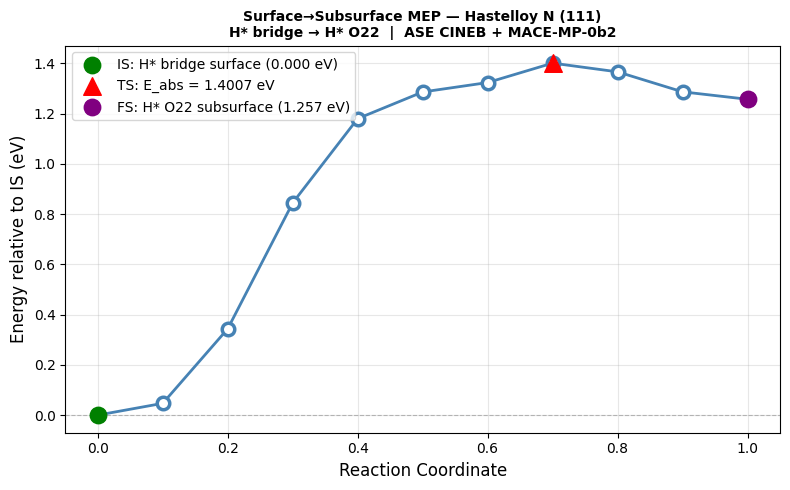

Saved: results/notebook09/fig_mep.png

E_abs   = 1.4007 eV  (TS at image 7)
delta_E = 1.2569 eV


In [8]:
# ─────────────────────────────────────────────────────────────
# Plot minimum energy path (MEP)
# ─────────────────────────────────────────────────────────────

if neb09_path_data is None:
    neb09_path_data = parse_neb_path('results/notebook09/neb09_path.dat')

if neb09_path_data is None:
    print('neb09_path.dat not found — run NEB job first.')
else:
    rxn_coord = neb09_path_data[:, 0]   # image fraction 0→1
    e_rel     = neb09_path_data[:, 2]   # dE from IS in eV
    ts_idx    = int(np.argmax(e_rel))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(rxn_coord, e_rel, 'o-', color='steelblue',
            lw=2, ms=9, mfc='white', mew=2.5, zorder=3)
    ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)

    ax.scatter([rxn_coord[0]], [e_rel[0]], s=140,
               color='green', zorder=5,
               label=f'IS: H* bridge surface ({e_rel[0]:.3f} eV)')
    ax.scatter([rxn_coord[ts_idx]], [e_rel[ts_idx]], s=160,
               color='red', marker='^', zorder=5,
               label=f'TS: E_abs = {e_rel[ts_idx]:.4f} eV')
    ax.scatter([rxn_coord[-1]], [e_rel[-1]], s=140,
               color='purple', zorder=5,
               label=f'FS: H* {BEST_SUB_LABEL} subsurface ({e_rel[-1]:.3f} eV)')

    ax.set_xlabel('Reaction Coordinate', fontsize=12)
    ax.set_ylabel('Energy relative to IS (eV)', fontsize=12)
    ax.set_title(f'Surface→Subsurface MEP — Hastelloy N (111)\n'
                 f'H* bridge → H* {BEST_SUB_LABEL}  |  ASE CINEB + MACE-MP-0b2',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/notebook09/fig_mep.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook09/fig_mep.png')
    print()
    print(f'E_abs   = {e_rel[ts_idx]:.4f} eV  (TS at image {ts_idx})')
    print(f'delta_E = {e_rel[-1]:.4f} eV')

### 3.7 — Decision Cell

In [9]:
# ─────────────────────────────────────────────────────────────
# Notebook 09 — Final Decision
# ─────────────────────────────────────────────────────────────

print('=' * 62)
print('  NOTEBOOK 09 — FINAL DECISION')
print('=' * 62)

E_abs_final = barrier.get('E_abs')    if barrier else None
E_des_final = barrier.get('E_des')    if barrier else None
dE_final    = barrier.get('delta_E')  if barrier else None
E_FS_final  = barrier.get('E_FS')     if barrier else None

checks = [
    ('IS file exists (H* bridge, NB06)',
     os.path.exists(NEB09_IS_FILE)),
    ('FS file exists (subsurface, NB08)',
     os.path.exists(NEB09_FS_FILE)),
    ('NEB barrier file written',
     os.path.exists('results/notebook09/neb09_barrier.txt')),
    ('NEB path file written',
     os.path.exists('results/notebook09/neb09_path.dat')),
    ('E_IS from log — no hardcoding',
     'E_IS' in dir() and E_IS is not None),
    ('E_FS from log — no hardcoding',
     'E_FS' in dir() and E_FS is not None),
    ('E_abs extracted',
     E_abs_final is not None),
    ('E_abs physical (0 to 2 eV)',
     E_abs_final is not None and 0.0 <= E_abs_final <= 2.0),
    ('MEP plot saved',
     os.path.exists('results/notebook09/fig_mep.png')),
]

all_pass = True
for label, ok in checks:
    print(f'  {"ok" if ok else "FAIL"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass:
    print('  ALL CHECKS PASSED')
    print()
    print(f'  IS      : H* at bridge (surface)')
    print(f'  FS      : H* at {BEST_SUB_LABEL} (subsurface)')
    print(f'  E_IS    : {E_IS:.6f} eV')
    print(f'  E_FS    : {E_FS_final:.6f} eV')
    print(f'  E_abs   : {E_abs_final:.4f} eV  (absorption IS→TS)')
    print(f'  E_des   : {E_des_final:.4f} eV  (desorption FS→TS)')
    print(f'  delta_E : {dE_final:.4f} eV')
    print()
    print('  Proceed to Notebook 10 (Bulk Equilibration)')
else:
    print('  CHECKS FAILED — resolve all FAIL items above')

print('=' * 62)

  NOTEBOOK 09 — FINAL DECISION
  ok IS file exists (H* bridge, NB06)
  ok FS file exists (subsurface, NB08)
  ok NEB barrier file written
  ok NEB path file written
  ok E_IS from log — no hardcoding
  ok E_FS from log — no hardcoding
  ok E_abs extracted
  ok E_abs physical (0 to 2 eV)
  ok MEP plot saved

  ALL CHECKS PASSED

  IS      : H* at bridge (surface)
  FS      : H* at O22 (subsurface)
  E_IS    : -2395.499210 eV
  E_FS    : -2394.242354 eV
  E_abs   : 1.4007 eV  (absorption IS→TS)
  E_des   : 0.1438 eV  (desorption FS→TS)
  delta_E : 1.2569 eV

  Proceed to Notebook 10 (Bulk Equilibration)


---
## 4. Notes & Next Step
---

### 4.1 — Your Observations (fill in after running)

```
Date run          : _______________
E_abs             : _______________  eV  (surface → bulk)
E_des             : _______________  eV  (bulk → surface)
ΔE (FS-IS)        : _______________  eV
NEB converged?    : _______________
Wall time         : _______________
Notes             : _______________
```

---
### 4.2 — Known Limitations

1. **4 replicas:** Sufficient for a simple 1-step surface→subsurface path.
2. **FIRE vs quickmin:** Equivalent convergence — FIRE used because it has `fire/kk` Kokkos variant.
3. **Static 0 K barrier:** No ZPE or thermal corrections (~0.05-0.1 eV for H).

---
### 4.3 — What Comes Next

**Notebook 10: Bulk Equilibration**
- Build 3×3×3 bulk supercell + 1 H atom at octahedral interstitial
- NVT equilibration at 300, 400, 600, 800 K
- Output: equilibrated structures for MSD diffusivity (NB11)

> **Checkpoint:** `results/neb09_barrier.txt` exists with E_abs and E_des.

---
## 5. References
---

**ACS citation style.**

**[1]** Ward, T. L.; Dao, T. Model of hydrogen permeation behavior in palladium membranes. *J. Membr. Sci.* **1999**, *153*, 211–231.

**[2]** Wimmer, E. et al. Temperature-dependent diffusion coefficients from ab initio computations: Hydrogen, deuterium, and tritium in nickel. *Phys. Rev. B* **2008**, *77*, 134305.

**[3]** Jiang, D. E.; Carter, E. A. Diffusion of interstitial hydrogen into and through bcc Fe from first principles. *Phys. Rev. B* **2004**, *70*, 064102.

**[4]** Jónsson, H.; Mills, G.; Jacobsen, K. W. Nudged elastic band method for finding minimum energy paths of transitions. In *Classical and Quantum Dynamics in Condensed Phase Simulations*; World Scientific, 1998; pp 385–404.

**[5]** Henkelman, G.; Uberuaga, B. P.; Jónsson, H. A climbing image nudged elastic band method for finding saddle points and minimum energy paths. *J. Chem. Phys.* **2000**, *113*, 9901–9904.

**[6]** Bitzek, E.; Koskinen, P.; Gähler, F.; Moseler, M.; Gumbsch, P. Structural relaxation made simple. *Phys. Rev. Lett.* **2006**, *97*, 170201.

**[7]** Batatia, I. et al. MACE: Higher order equivariant message passing neural networks for fast and accurate force fields. *Adv. Neural Inf. Process. Syst.* **2022**, *35*, 11423–11436.

**[8]** Batatia, I. et al. A foundation model for atomistic materials chemistry. *arXiv* **2023**, 2401.00096.